# 01 - EDA y Preprocesamiento

Análisis exploratorio, limpieza y preparación de datos tabulares para detección de malware Android.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print('✓ Librerías importadas')

✓ Librerías importadas


## 1. Carga y Validación Inicial

In [2]:
# Rutas
data_path = 'Multimodal_CIC-MalDroid2020/Tabular/'

# Cargar datos
df_train = pd.read_csv(f'{data_path}train-tabular.csv')
df_test = pd.read_csv(f'{data_path}test-tabular.csv')

print('TRAIN DATA')
print(f'  Shape: {df_train.shape}')
print(f'  Features: {df_train.shape[1] - 2}')
print(f'  Null values: {df_train.isnull().sum().sum()}')

print('\nTEST DATA')
print(f'  Shape: {df_test.shape}')
print(f'  Null values: {df_test.isnull().sum().sum()}')

# Distribución de clases
print('\nCLASE DISTRIBUTION (TRAIN):')
print(df_train['Class'].value_counts().sort_index())
print('\nCLASE DISTRIBUTION (TEST):')
print(df_test['Class'].value_counts().sort_index())

TRAIN DATA
  Shape: (11683, 402)
  Features: 400
  Null values: 0

TEST DATA
  Shape: (5008, 402)
  Null values: 0

CLASE DISTRIBUTION (TRAIN):
Class
adware      1061
banking     1733
benign      2821
riskware    2727
sms         3341
Name: count, dtype: int64

CLASE DISTRIBUTION (TEST):
Class
adware       450
banking      720
benign      1209
riskware    1165
sms         1464
Name: count, dtype: int64


## 2. Análisis Exploratorio Univariado

In [3]:
# Separar features de etiquetas
feature_cols = [col for col in df_train.columns if col not in ['apk_name', 'Class']]
print(f'Total de features: {len(feature_cols)}')
print(f'Primeras 10: {feature_cols[:10]}')

X_train = df_train[feature_cols].copy()
y_train = df_train['Class'].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test['Class'].copy()

# Análisis de sparsity
print('\nSPARSITY ANALYSIS:')
zeros_per_feature = (X_train == 0).sum() / len(X_train) * 100
print(f'  Media de ceros: {zeros_per_feature.mean():.2f}%')
print(f'  Min: {zeros_per_feature.min():.2f}%, Max: {zeros_per_feature.max():.2f}%')

# Variables constantes
constant_features = X_train.columns[X_train.var() == 0].tolist()
print(f'\nVariables constantes (var=0): {len(constant_features)}')
if constant_features:
    print(f'  Ejemplos: {constant_features[:5]}')

# Variables quasi-constantes (baja varianza)
quasi_const = X_train.columns[X_train.var() < 0.01].tolist()
print(f'\nVariables quasi-constantes (var<0.01): {len(quasi_const)}')

Total de features: 400
Primeras 10: ['permission.CALL_PHONE', 'permission.INTERNET', 'permission.READ_EXTERNAL_STORAGE', 'permission.READ_PHONE_STATE', 'permission.WRITE_EXTERNAL_STORAGE', 'permission.WRITE_SMS', 'permission.INSTALL_SHORTCUT', 'permission.C2D_MESSAGE', 'permission.ACCESS_NETWORK_STATE', 'permission.RECEIVE_BOOT_COMPLETED']

SPARSITY ANALYSIS:
  Media de ceros: 96.88%
  Min: 1.51%, Max: 100.00%

Variables constantes (var=0): 19
  Ejemplos: ['MyLocationService', 'action.SEND_TO_KPSH', 'MvService', 'action.LOCKER_ACTIVE', 'action.widget.click']

Variables quasi-constantes (var<0.01): 323


## 3. Análisis de Correlaciones y Redundancia

Calculando matriz de correlación...

Pares altamente correlacionados (corr > 0.95): 0


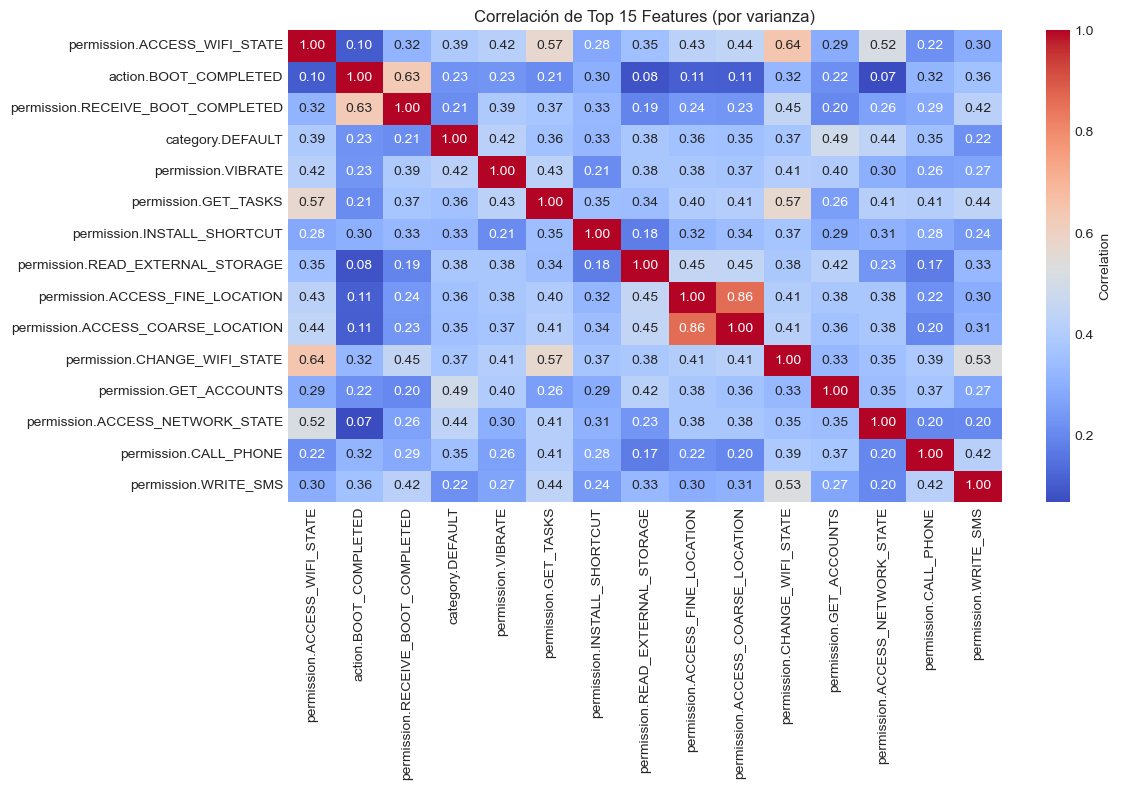

✓ Figura guardada: reports/01_correlation_matrix.png


In [11]:
import os

# Matriz de correlación (sample para visualización)
print('Calculando matriz de correlación...')
corr_matrix = X_train.corr()

# Variables altamente correlacionadas
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f'\nPares altamente correlacionados (corr > 0.95): {len(high_corr_pairs)}')
if high_corr_pairs:
    print('\nPrimeros 10 ejemplos:')
    for feat1, feat2, corr_val in high_corr_pairs[:10]:
        print(f'  {feat1} <-> {feat2}: {corr_val:.4f}')

# Visualizar top correlaciones
fig, ax = plt.subplots(figsize=(12, 8))
# Top features por varianza
top_features = X_train.var().nlargest(15).index.tolist()
sns.heatmap(X_train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, cbar_kws={'label': 'Correlation'})
plt.title('Correlación de Top 15 Features (por varianza)')
plt.tight_layout()

# Asegurar que la carpeta reports existe
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/01_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/01_correlation_matrix.png')

## 4. Separabilidad y Visualización PCA

Clases: ['adware' 'banking' 'benign' 'riskware' 'sms']

Aplicando PCA...
Varianza explicada (2 componentes): 0.3416
Varianza explicada (10 componentes): 0.6436
Varianza explicada (50 componentes): 0.9321


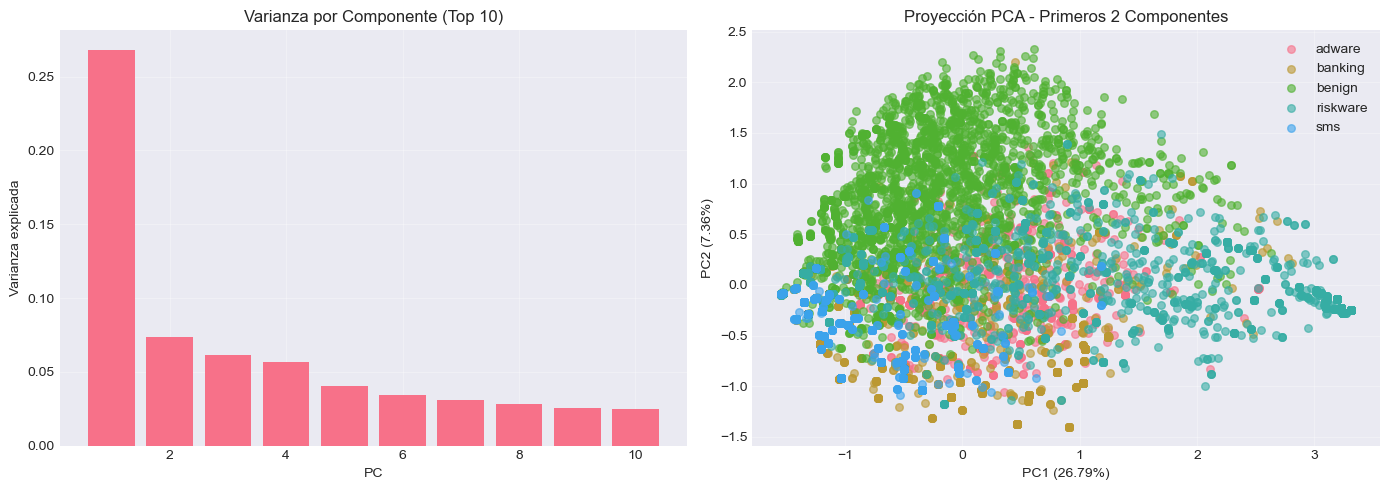

✓ Figura guardada: reports/02_pca_analysis.png


In [12]:
# Codificar clases para PCA
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

class_names = le.classes_
print(f'Clases: {class_names}')

# PCA
print('\nAplicando PCA...')
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)

print(f'Varianza explicada (2 componentes): {pca.explained_variance_ratio_[:2].sum():.4f}')
print(f'Varianza explicada (10 componentes): {pca.explained_variance_ratio_[:10].sum():.4f}')
print(f'Varianza explicada (50 componentes): {pca.explained_variance_ratio_[:50].sum():.4f}')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada
axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10])
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza por Componente (Top 10)')
axes[0].grid(alpha=0.3)

# Scatter PCA
for i, class_name in enumerate(class_names):
    mask = y_train_encoded == i
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                   label=class_name, alpha=0.6, s=30)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('Proyección PCA - Primeros 2 Componentes')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/02_pca_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/02_pca_analysis.png')

## 5. Limpieza: Eliminar Features Redundantes

In [13]:
# Eliminar variables constantes
features_to_keep = X_train.columns[(X_train.var() > 0)].tolist()
print(f'Eliminadas constantes: {len(feature_cols) - len(features_to_keep)}')

# Eliminar una variable de cada par altamente correlacionado
# (mantener la con mayor varianza)
remove_set = set()
for feat1, feat2, _ in high_corr_pairs:
    var1 = X_train[feat1].var()
    var2 = X_train[feat2].var()
    remove_set.add(feat2 if var1 > var2 else feat1)

features_to_keep = [f for f in features_to_keep if f not in remove_set]
print(f'Eliminadas por alta correlación: {len(remove_set)}')
print(f'Features finales: {len(features_to_keep)}')

# Aplicar limpieza
X_train = X_train[features_to_keep].copy()
X_test = X_test[features_to_keep].copy()

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

Eliminadas constantes: 55
Eliminadas por alta correlación: 0
Features finales: 345

X_train shape: (11683, 345)
X_test shape: (5008, 345)


## 6. Split Train/Val/Test Estratificado

In [14]:
# Split: Train (70%) + Val (15%) + Test (15%) estratificado
X_temp, X_test_split, y_temp, y_test_split = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

print('SPLIT SIZES:')
print(f'  Train: {X_train_split.shape[0]} ({100*len(X_train_split)/len(X_train):.1f}%)')
print(f'  Val:   {X_val.shape[0]} ({100*len(X_val)/len(X_train):.1f}%)')
print(f'  Test:  {X_test_split.shape[0]} ({100*len(X_test_split)/len(X_train):.1f}%)')

print('\nDISTRIBUCIÓN DE CLASES (TRAIN SPLIT):')
for class_name in class_names:
    count = (y_train_split == class_name).sum()
    pct = 100 * count / len(y_train_split)
    print(f'  {class_name:10s}: {count:5d} ({pct:5.2f}%)')

# Usar test del dataset original como test final
print('\nUsando test original del dataset como TEST FINAL')
X_test_final = X_test
y_test_final = y_test

print(f'Test final shape: {X_test_final.shape}')
print('\nDISTRIBUCIÓN DE CLASES (TEST FINAL):')
for class_name in class_names:
    count = (y_test_final == class_name).sum()
    pct = 100 * count / len(y_test_final)
    print(f'  {class_name:10s}: {count:5d} ({pct:5.2f}%)')

SPLIT SIZES:
  Train: 8182 (70.0%)
  Val:   1748 (15.0%)
  Test:  1753 (15.0%)

DISTRIBUCIÓN DE CLASES (TRAIN SPLIT):
  adware    :   743 ( 9.08%)
  banking   :  1214 (14.84%)
  benign    :  1976 (24.15%)
  riskware  :  1910 (23.34%)
  sms       :  2339 (28.59%)

Usando test original del dataset como TEST FINAL
Test final shape: (5008, 345)

DISTRIBUCIÓN DE CLASES (TEST FINAL):
  adware    :   450 ( 8.99%)
  banking   :   720 (14.38%)
  benign    :  1209 (24.14%)
  riskware  :  1165 (23.26%)
  sms       :  1464 (29.23%)


## 7. Escalado y Normalización

In [15]:
# Escalador
scaler = StandardScaler()

# Fit SOLO en train, luego transform todo
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print('ESTADÍSTICAS POST-ESCALADO (Train):')
print(f'  Mean: {X_train_scaled.mean():.6f}')
print(f'  Std:  {X_train_scaled.std():.6f}')
print(f'  Min:  {X_train_scaled.min():.4f}')
print(f'  Max:  {X_train_scaled.max():.4f}')

# Codificar clases
y_train_enc = le.transform(y_train_split)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test_final)

print(f'\nClases codificadas: {dict(zip(class_names, range(len(class_names))))}')

ESTADÍSTICAS POST-ESCALADO (Train):
  Mean: -0.000000
  Std:  0.969087
  Min:  -8.3025
  Max:  90.4489

Clases codificadas: {'adware': 0, 'banking': 1, 'benign': 2, 'riskware': 3, 'sms': 4}


## 8. Guardar Datos Procesados

In [16]:
import os
import pickle

# Crear carpeta
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Guardar datos
np.save('data/processed/X_train_scaled.npy', X_train_scaled)
np.save('data/processed/X_val_scaled.npy', X_val_scaled)
np.save('data/processed/X_test_scaled.npy', X_test_scaled)
np.save('data/processed/y_train_enc.npy', y_train_enc)
np.save('data/processed/y_val_enc.npy', y_val_enc)
np.save('data/processed/y_test_enc.npy', y_test_enc)

# Guardar metadatos
metadata = {
    'feature_names': features_to_keep,
    'class_names': class_names,
    'n_features': len(features_to_keep),
    'n_classes': len(class_names),
    'shapes': {
        'X_train': X_train_scaled.shape,
        'X_val': X_val_scaled.shape,
        'X_test': X_test_scaled.shape
    }
}

with open('data/processed/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

# Guardar escalador
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✓ Datos guardados en data/processed/')
print('✓ Scaler guardado en models/scaler.pkl')
print('✓ Label Encoder guardado en models/label_encoder.pkl')
print(f'\nRESUMEN PREPROCESAMIENTO:')
print(f'  Features originales: 400')
print(f'  Features finales: {len(features_to_keep)}')
print(f'  Reducción: {100*(400-len(features_to_keep))/400:.1f}%')
print(f'  Train samples: {X_train_scaled.shape[0]}')
print(f'  Val samples: {X_val_scaled.shape[0]}')
print(f'  Test samples: {X_test_scaled.shape[0]}')

✓ Datos guardados en data/processed/
✓ Scaler guardado en models/scaler.pkl
✓ Label Encoder guardado en models/label_encoder.pkl

RESUMEN PREPROCESAMIENTO:
  Features originales: 400
  Features finales: 345
  Reducción: 13.8%
  Train samples: 8182
  Val samples: 1748
  Test samples: 5008
